<a href="https://www.kaggle.com/code/hisyamsyafaraditya/final-project-machine-learning?scriptVersionId=325032767" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Import Libraries

In [1]:
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

# Load Dataset

In [2]:
train_df = pd.read_csv("/kaggle/input/datasets/stealthtechnologies/employee-attrition-dataset/train.csv")
test_df = pd.read_csv("/kaggle/input/datasets/stealthtechnologies/employee-attrition-dataset/test.csv")

# Data Understanding

## Dataset Overview

### Training Set

In [3]:
display(train_df.head())

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


In [4]:
print("Train Dataset Information")
print(f"Jumlah baris : {train_df.shape[0]}")
print(f"Jumlah baris : {train_df.shape[1]}")

Train Dataset Information
Jumlah baris : 59598
Jumlah baris : 24


### Testing Set

In [5]:
display(test_df.head())

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,52685,36,Male,13,Healthcare,8029,Excellent,High,Average,1,...,1,Mid,Large,22,No,No,No,Poor,Medium,Stayed
1,30585,35,Male,7,Education,4563,Good,High,Average,1,...,4,Entry,Medium,27,No,No,No,Good,High,Left
2,54656,50,Male,7,Education,5583,Fair,High,Average,3,...,2,Senior,Medium,76,No,No,Yes,Good,Low,Stayed
3,33442,58,Male,44,Media,5525,Fair,Very High,High,0,...,4,Entry,Medium,96,No,No,No,Poor,Low,Left
4,15667,39,Male,24,Education,4604,Good,High,Average,0,...,6,Mid,Large,45,Yes,No,No,Good,High,Stayed


In [6]:
print("Test Dataset Information")
print(f"Jumlah baris : {test_df.shape[0]}")
print(f"Jumlah baris : {test_df.shape[1]}")

Test Dataset Information
Jumlah baris : 14900
Jumlah baris : 24


## Statistical Summary

### Training Set

In [7]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Employee ID,59598.0,37227.118729,21519.150028,1.0,18580.25,37209.5,55876.75,74498.0
Age,59598.0,38.565875,12.079673,18.0,28.00,39.0,49.00,59.0
Years at Company,59598.0,15.753901,11.245981,1.0,7.00,13.0,23.00,51.0
Monthly Income,59598.0,7302.397983,2151.457423,1316.0,5658.00,7354.0,8880.00,16149.0
Number of Promotions,59598.0,0.832578,0.994991,0.0,0.00,1.0,2.00,4.0
Distance from Home,59598.0,50.007651,28.466459,1.0,25.00,50.0,75.00,99.0
Number of Dependents,59598.0,1.648075,1.555689,0.0,0.00,1.0,3.00,6.0
Company Tenure,59598.0,55.758415,25.411090,2.0,36.00,56.0,76.00,128.0


### Testing Set

In [8]:
test_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Employee ID,14900.0,37339.022081,21453.129293,5.0,18825.50,37433.0,55857.5,74471.0
Age,14900.0,38.385235,12.097904,18.0,28.00,38.0,49.0,59.0
Years at Company,14900.0,15.592416,11.133792,1.0,7.00,13.0,23.0,51.0
Monthly Income,14900.0,7287.306040,2156.737934,1226.0,5633.75,7332.0,8852.0,15063.0
Number of Promotions,14900.0,0.834362,0.996511,0.0,0.00,1.0,2.0,4.0
Distance from Home,14900.0,49.927315,28.702307,1.0,25.00,50.0,75.0,99.0
Number of Dependents,14900.0,1.659329,1.545401,0.0,0.00,1.0,3.0,6.0
Company Tenure,14900.0,55.603624,25.352807,2.0,36.00,56.0,75.0,127.0


## Feature Types

### Training Set

In [9]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59598 entries, 0 to 59597
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               59598 non-null  int64 
 1   Age                       59598 non-null  int64 
 2   Gender                    59598 non-null  object
 3   Years at Company          59598 non-null  int64 
 4   Job Role                  59598 non-null  object
 5   Monthly Income            59598 non-null  int64 
 6   Work-Life Balance         59598 non-null  object
 7   Job Satisfaction          59598 non-null  object
 8   Performance Rating        59598 non-null  object
 9   Number of Promotions      59598 non-null  int64 
 10  Overtime                  59598 non-null  object
 11  Distance from Home        59598 non-null  int64 
 12  Education Level           59598 non-null  object
 13  Marital Status            59598 non-null  object
 14  Number of Dependents  

### Testing Set

In [10]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14900 entries, 0 to 14899
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               14900 non-null  int64 
 1   Age                       14900 non-null  int64 
 2   Gender                    14900 non-null  object
 3   Years at Company          14900 non-null  int64 
 4   Job Role                  14900 non-null  object
 5   Monthly Income            14900 non-null  int64 
 6   Work-Life Balance         14900 non-null  object
 7   Job Satisfaction          14900 non-null  object
 8   Performance Rating        14900 non-null  object
 9   Number of Promotions      14900 non-null  int64 
 10  Overtime                  14900 non-null  object
 11  Distance from Home        14900 non-null  int64 
 12  Education Level           14900 non-null  object
 13  Marital Status            14900 non-null  object
 14  Number of Dependents  

# Exploratory Data Analysis (EDA)

## Missing Value Check

In [11]:
print(train_df.isnull().sum())

Employee ID                 0
Age                         0
Gender                      0
Years at Company            0
Job Role                    0
Monthly Income              0
Work-Life Balance           0
Job Satisfaction            0
Performance Rating          0
Number of Promotions        0
Overtime                    0
Distance from Home          0
Education Level             0
Marital Status              0
Number of Dependents        0
Job Level                   0
Company Size                0
Company Tenure              0
Remote Work                 0
Leadership Opportunities    0
Innovation Opportunities    0
Company Reputation          0
Employee Recognition        0
Attrition                   0
dtype: int64


## Duplicate Check

In [12]:
print("Duplicate rows :", train_df.duplicated().sum())

Duplicate rows : 0


## Class Distribution

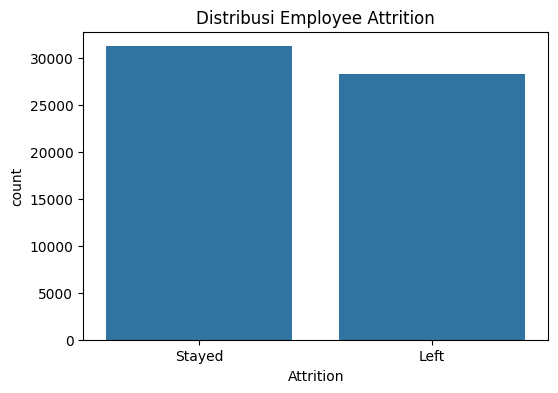

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=train_df,
    x='Attrition'
)

plt.title('Distribusi Employee Attrition')
plt.show()

In [14]:
print(train_df['Attrition'].value_counts())
print(train_df['Attrition'].value_counts(normalize=True)*100)

Attrition
Stayed    31260
Left      28338
Name: count, dtype: int64
Attrition
Stayed    52.451425
Left      47.548575
Name: proportion, dtype: float64


## Numerical Feature Analysis

In [15]:
numerical_cols = [
    'Age',
    'Years at Company',
    'Monthly Income',
    'Number of Promotions',
    'Distance from Home',
    'Company Tenure',
    'Number of Dependents'
]

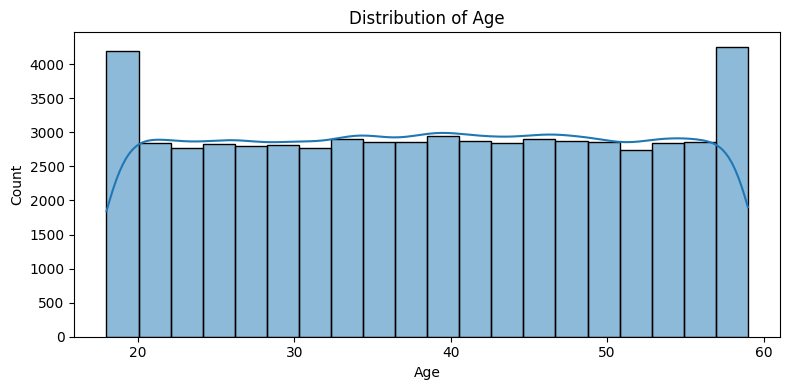

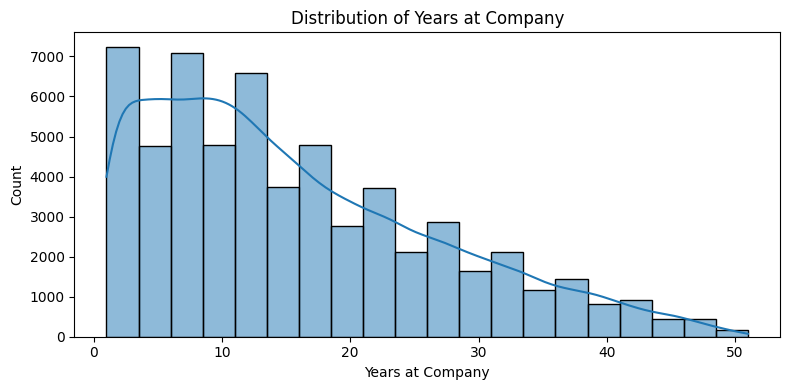

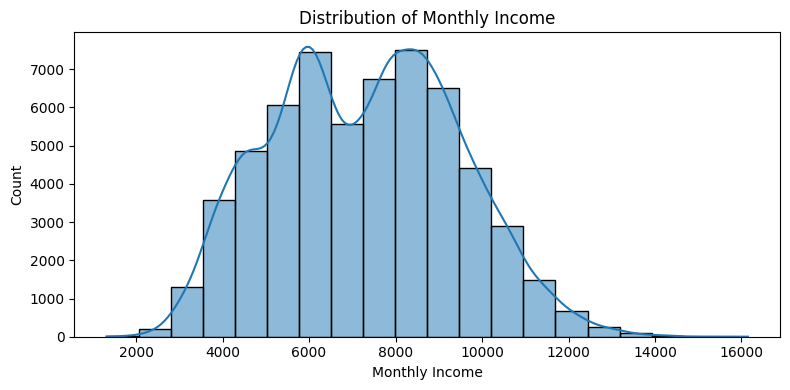

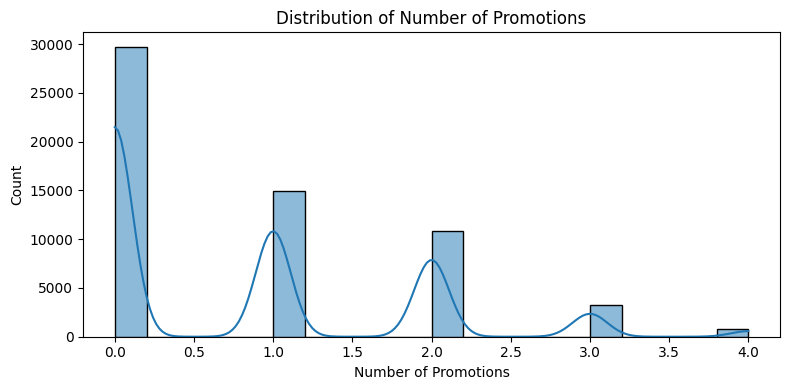

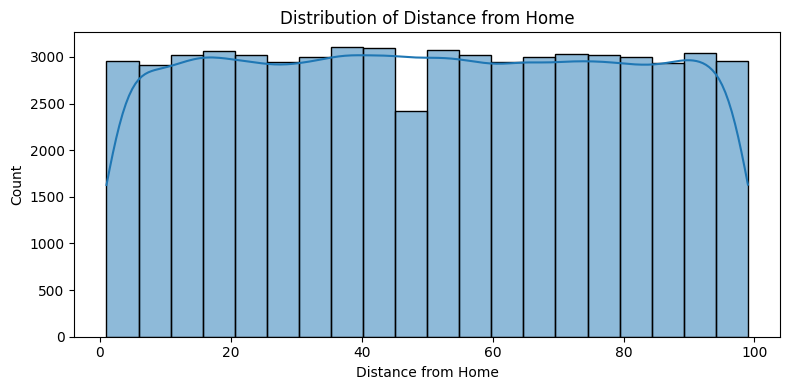

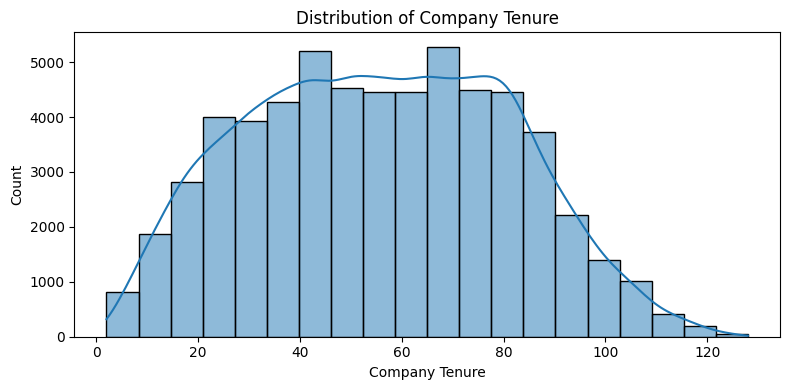

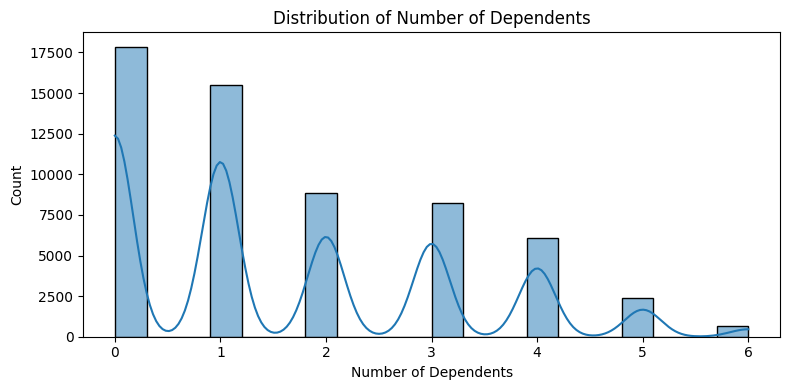

In [16]:
for col in numerical_cols:
    plt.figure(figsize=(8, 4))

    sns.histplot(
        data=train_df,
        x=col,
        bins=20,
        kde=True
    )

    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

## Categorical Feature Analysis

In [17]:
categorical_cols = [
    'Gender',
    'Job Role',
    'Work-Life Balance',
    'Job Satisfaction',
    'Performance Rating',
    'Overtime',
    'Education Level',
    'Marital Status',
    'Job Level',
    'Company Size',
    'Remote Work',
    'Leadership Opportunities',
    'Innovation Opportunities',
    'Company Reputation',
    'Employee Recognition'
]

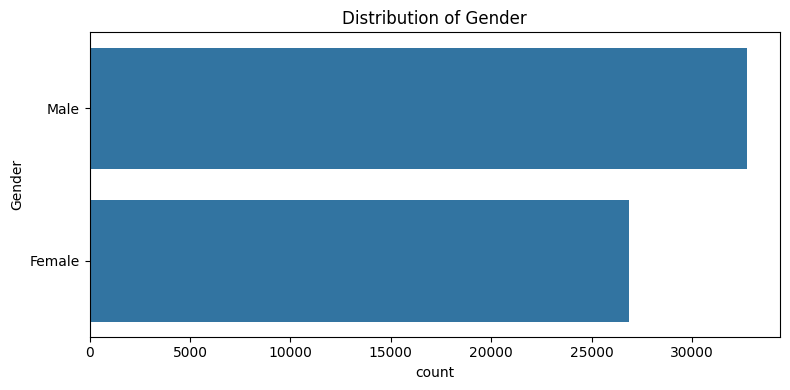

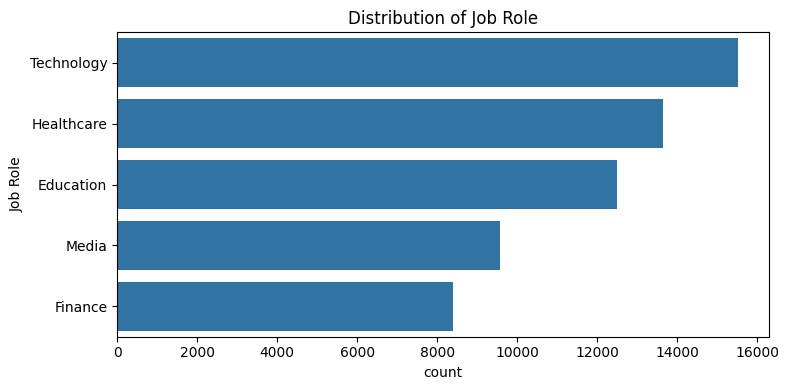

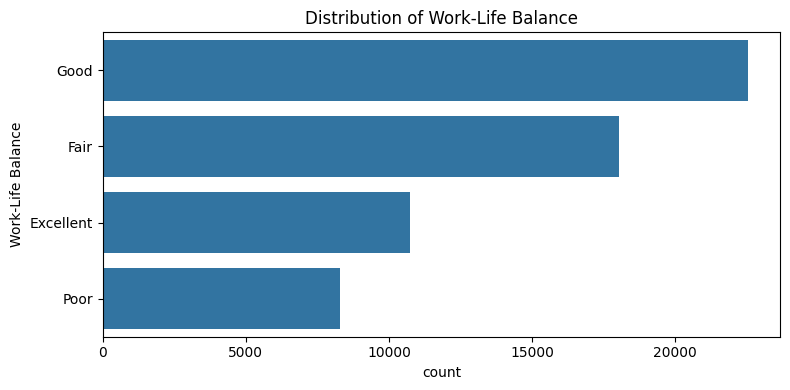

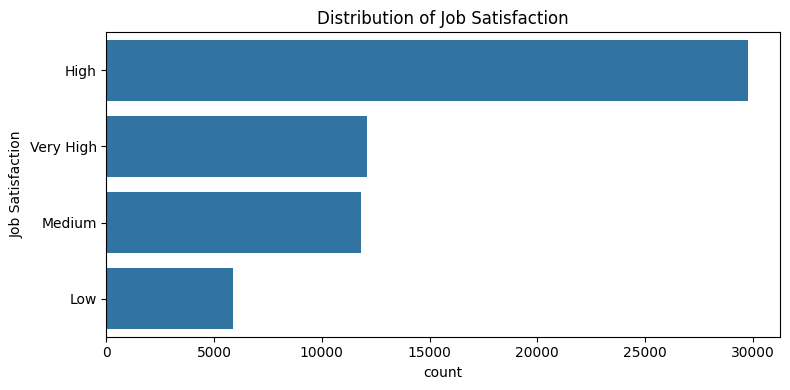

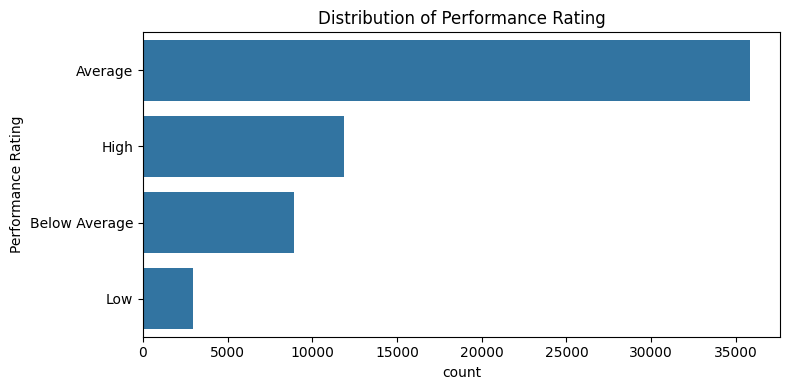

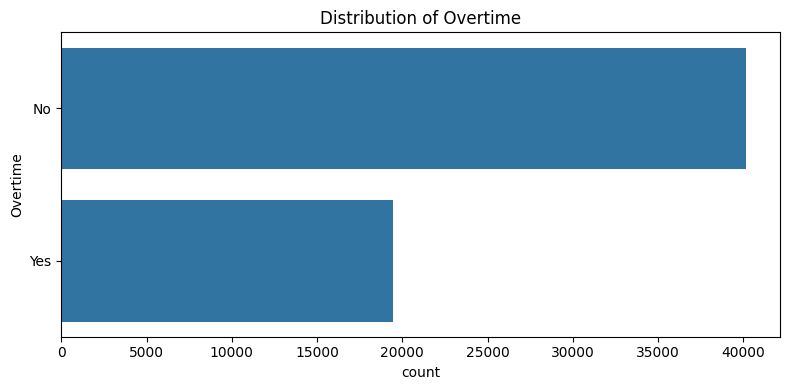

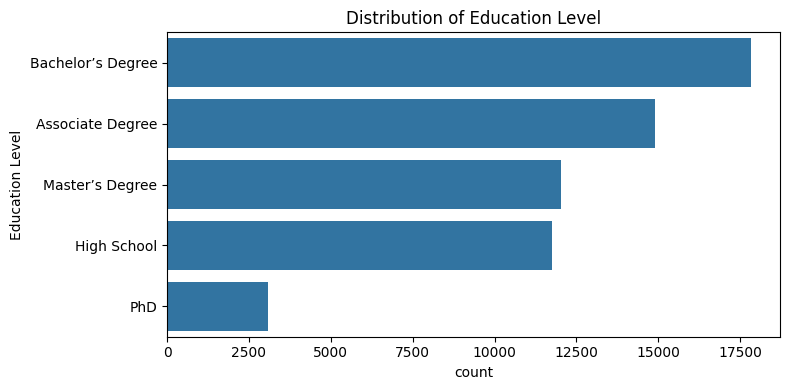

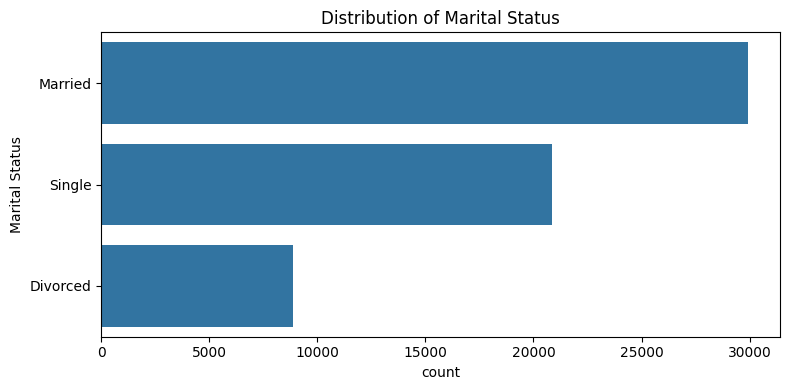

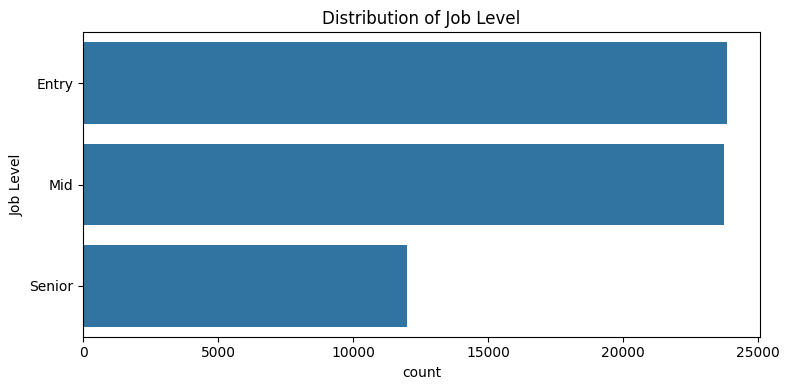

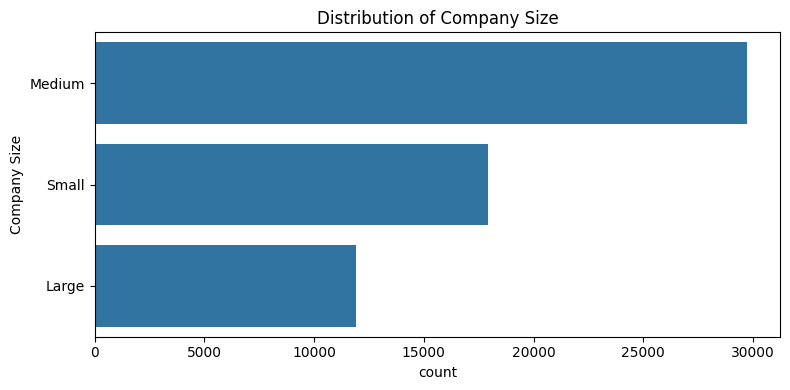

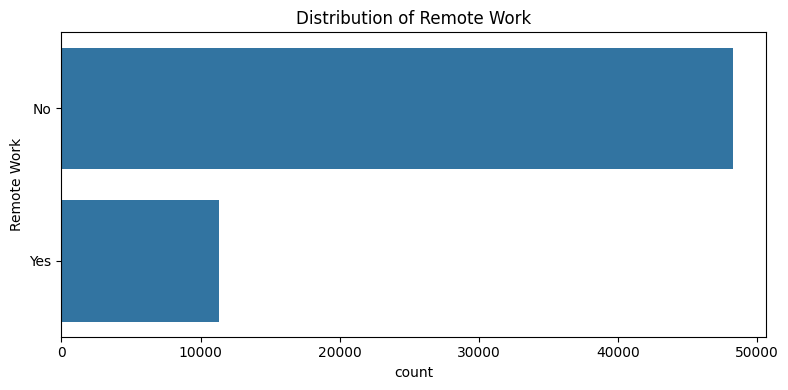

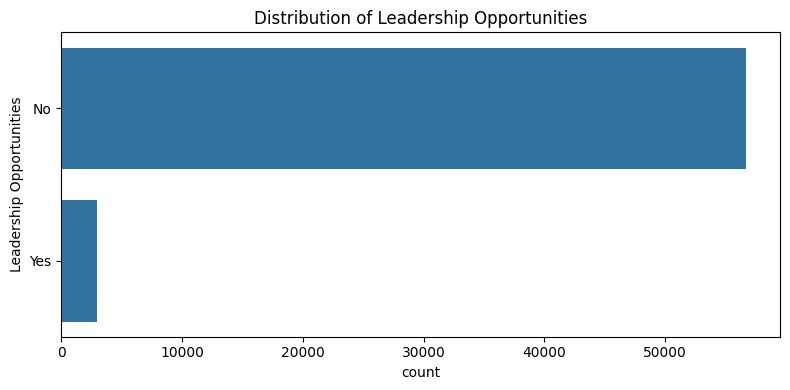

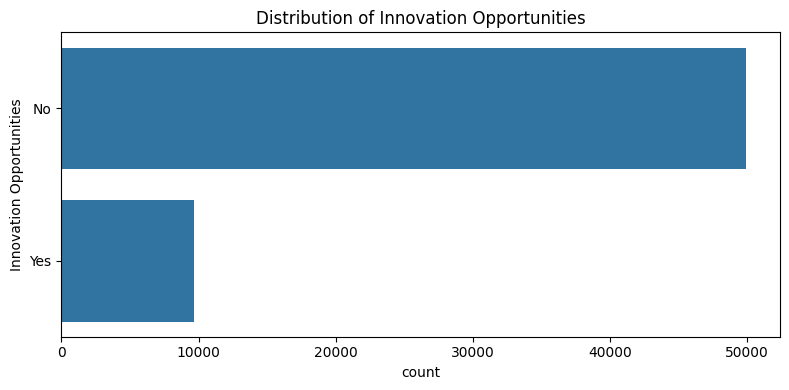

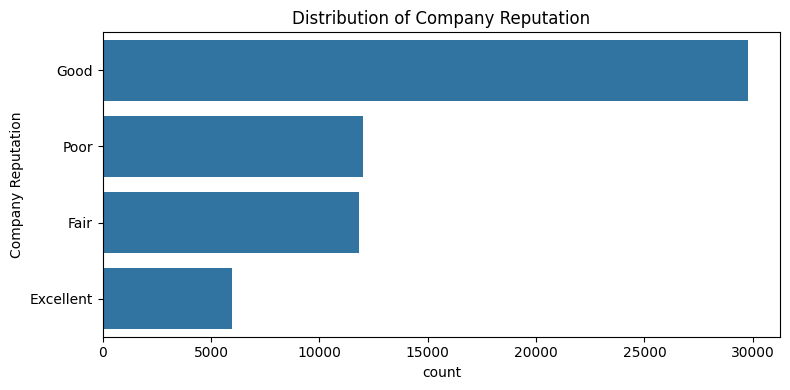

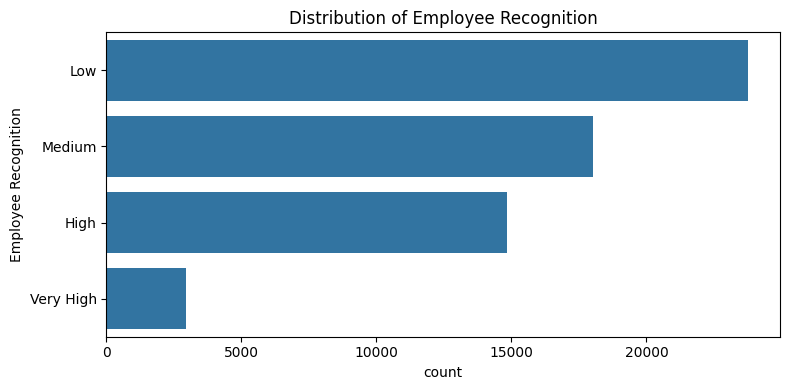

In [18]:
for col in categorical_cols:
    plt.figure(figsize=(8, 4))

    sns.countplot(
        data=train_df,
        y=col,
        order=train_df[col].value_counts().index
    )

    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

## Feature-Target Relationships

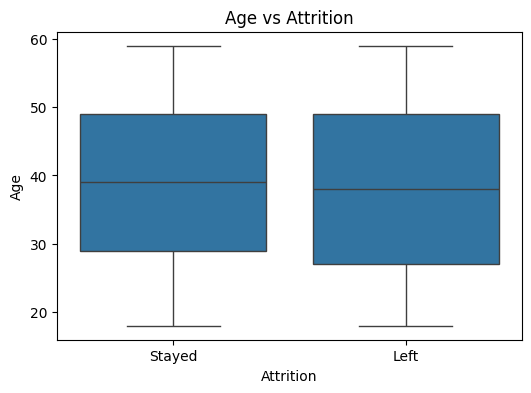

In [19]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=train_df,
    x='Attrition',
    y='Age'
)

plt.title('Age vs Attrition')
plt.show()

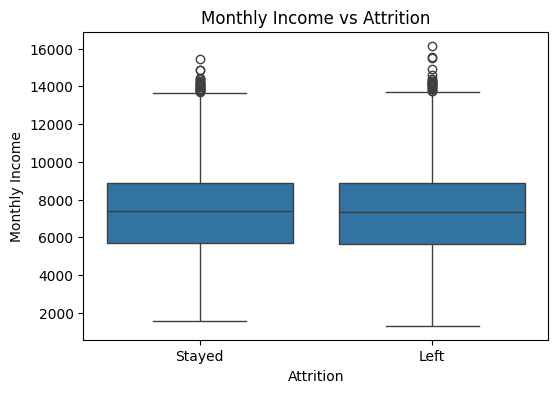

In [20]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=train_df,
    x='Attrition',
    y='Monthly Income'
)

plt.title('Monthly Income vs Attrition')
plt.show()

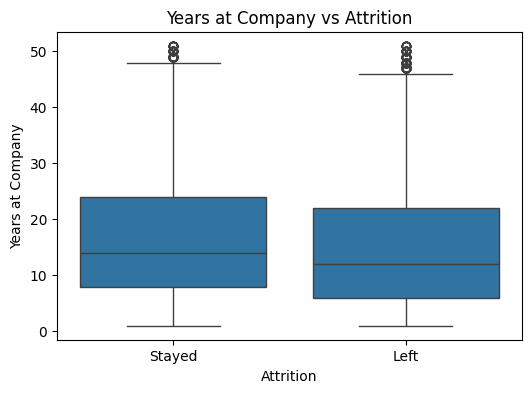

In [21]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=train_df,
    x='Attrition',
    y='Years at Company'
)

plt.title('Years at Company vs Attrition')
plt.show()

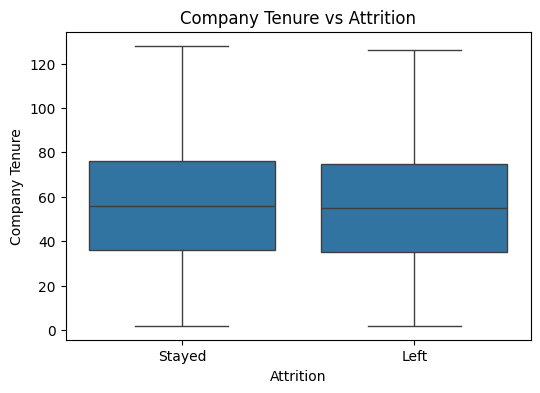

In [22]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=train_df,
    x='Attrition',
    y='Company Tenure'
)

plt.title('Company Tenure vs Attrition')
plt.show()

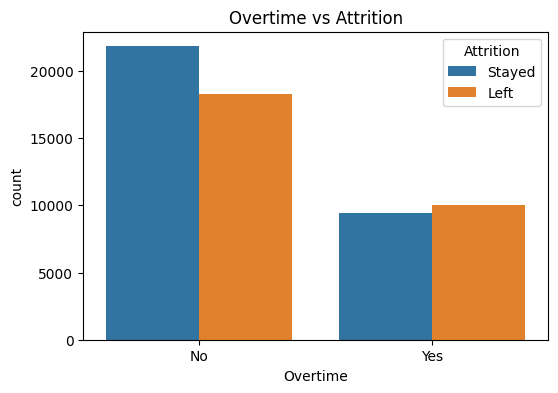

In [23]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=train_df,
    x='Overtime',
    hue='Attrition'
)

plt.title('Overtime vs Attrition')
plt.show()

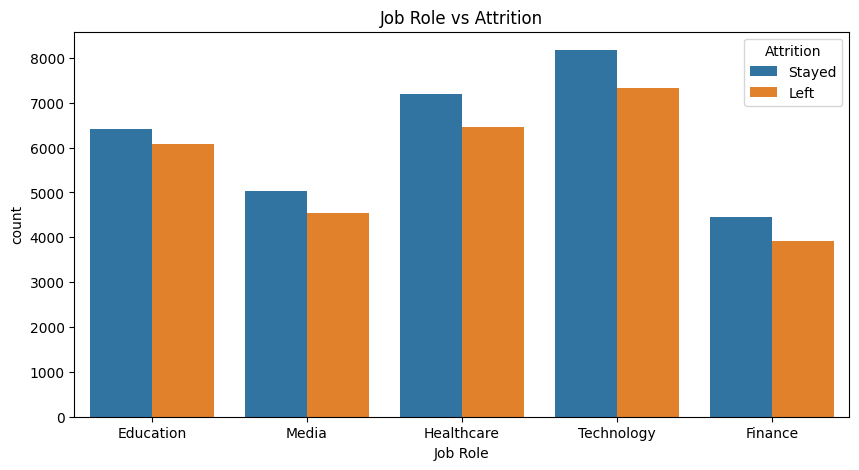

In [24]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=train_df,
    x='Job Role',
    hue='Attrition'
)

plt.title('Job Role vs Attrition')
plt.show()

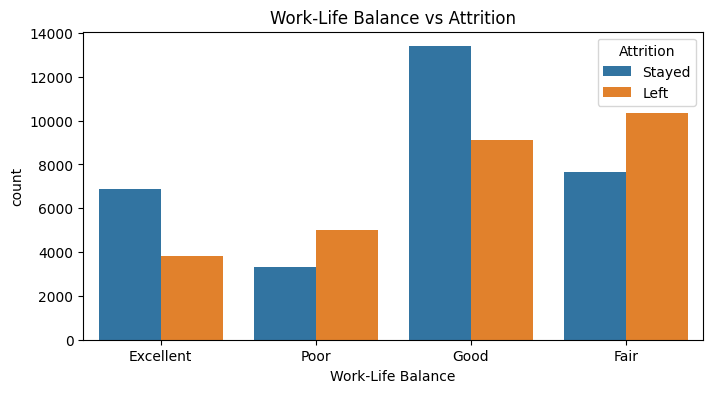

In [25]:
plt.figure(figsize=(8,4))

sns.countplot(
    data=train_df,
    x='Work-Life Balance',
    hue='Attrition'
)

plt.title('Work-Life Balance vs Attrition')
plt.show()

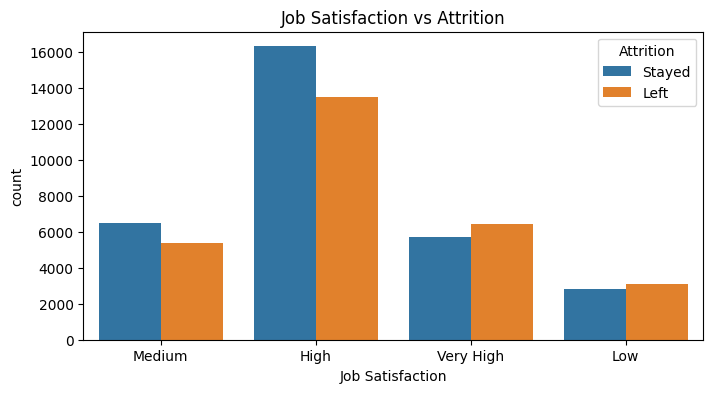

In [26]:
plt.figure(figsize=(8,4))

sns.countplot(
    data=train_df,
    x='Job Satisfaction',
    hue='Attrition'
)

plt.title('Job Satisfaction vs Attrition')
plt.show()

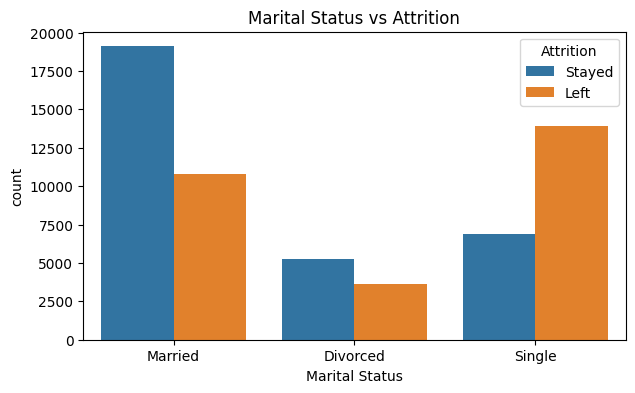

In [27]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=train_df,
    x='Marital Status',
    hue='Attrition'
)

plt.title('Marital Status vs Attrition')
plt.show()

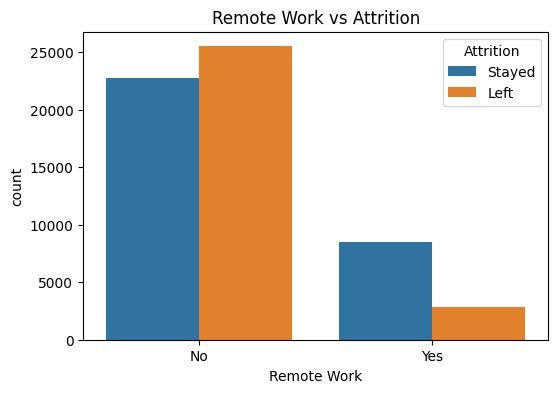

In [28]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=train_df,
    x='Remote Work',
    hue='Attrition'
)

plt.title('Remote Work vs Attrition')
plt.show()

## Heatmap (Correlation Matrix)

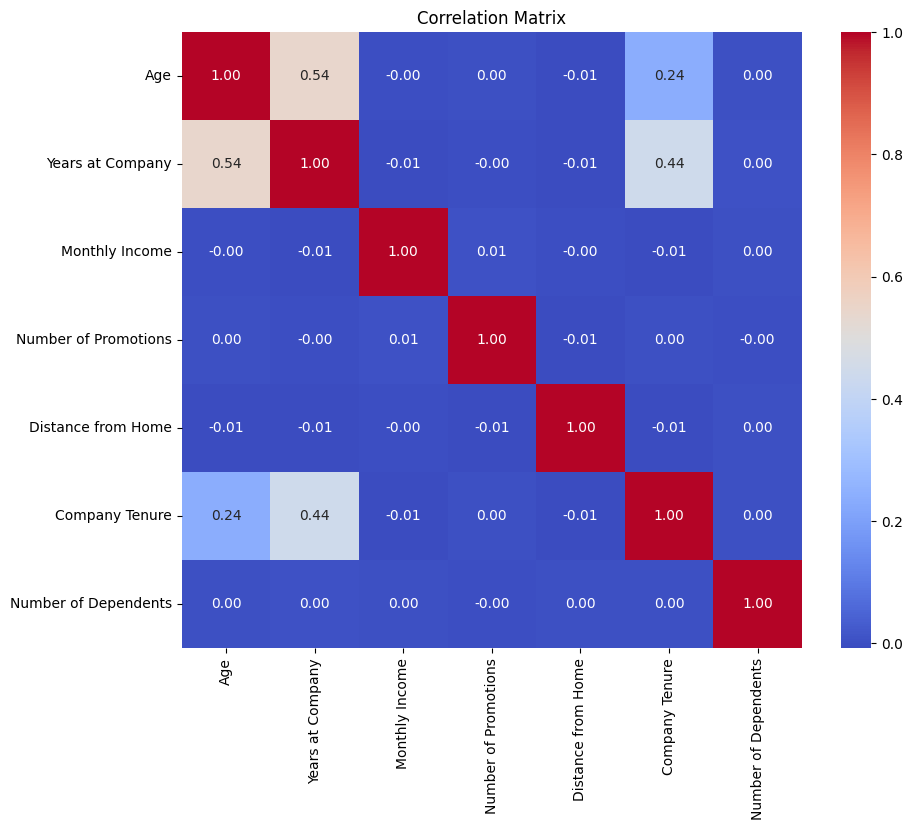

In [29]:
plt.figure(figsize=(10,8))

corr = train_df[numerical_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

# Data Preprocessing

## Feature Selection

In [30]:
X_train = train_df.drop(columns=['Employee ID', 'Attrition'])
y_train = train_df['Attrition']

In [31]:
X_test = test_df.drop(columns=['Employee ID', 'Attrition'])
y_test = test_df['Attrition']

## Encode Target Variable

In [32]:
target_encoder = LabelEncoder()

In [33]:
y_train = target_encoder.fit_transform(y_train)
y_test = target_encoder.transform(y_test)

## Encode Categorical Features

In [34]:
onehot_encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

In [35]:
X_train_categorical_encoded = onehot_encoder.fit_transform(X_train[categorical_cols])
X_test_categorical_encoded = onehot_encoder.transform(X_test[categorical_cols])

In [36]:
encoded_feature_names = onehot_encoder.get_feature_names_out(categorical_cols)

In [37]:
X_train_categorical_encoded_df = pd.DataFrame(X_train_categorical_encoded, columns=encoded_feature_names, index=X_train.index)
X_test_categorical_encoded_df = pd.DataFrame(X_test_categorical_encoded, columns=encoded_feature_names, index=X_test.index)

## Feature Normalization

In [38]:
scaler = StandardScaler()

In [39]:
X_train_numerical_scaled = scaler.fit_transform(X_train[numerical_cols])
X_test_numerical_scaled = scaler.transform(X_test[numerical_cols])

In [40]:
X_train_numerical_scaled_df = pd.DataFrame(X_train_numerical_scaled, columns=numerical_cols, index=X_train.index)
X_test_numerical_scaled_df = pd.DataFrame(X_test_numerical_scaled, columns=numerical_cols, index=X_test.index)

## Merge Dataset

In [41]:
X_train_scaled = pd.concat([X_train_numerical_scaled_df, X_train_categorical_encoded_df], axis=1)
X_test_scaled = pd.concat([X_test_numerical_scaled_df, X_test_categorical_encoded_df], axis=1)

In [42]:
all_processed_cols = X_train_scaled.columns.union(X_test_scaled.columns)

In [43]:
X_train_scaled = X_train_scaled.reindex(columns=all_processed_cols, fill_value=0)
X_test_scaled = X_test_scaled.reindex(columns=all_processed_cols, fill_value=0)

In [44]:
display(X_train_scaled.head())

,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Company Tenure,Number of Dependents,Gender_Female,Gender_Male,Job Role_Education,...,Innovation Opportunities_No,Innovation Opportunities_Yes,Company Reputation_Excellent,Company Reputation_Fair,Company Reputation_Good,Company Reputation_Poor,Employee Recognition_High,Employee Recognition_Low,Employee Recognition_Medium,Employee Recognition_Very High
0,-0.626336,0.288648,-0.888892,1.173308,-0.983891,1.308164,-1.059395,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.691627,-1.045173,-0.821960,2.178351,-1.019020,-1.367856,0.869027,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,-1.205827,-0.511645,0.398153,-0.836777,-1.370314,0.717865,0.869027,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,-0.212414,-0.778409,-1.540084,0.168266,-0.808244,-0.226612,0.226220,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,1.443273,2.244918,-1.153366,-0.836777,0.737448,0.481746,-1.059395,0.0,1.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [45]:
display(X_test_scaled.head())

,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Company Tenure,Number of Dependents,Gender_Female,Gender_Male,Job Role_Education,...,Innovation Opportunities_No,Innovation Opportunities_Yes,Company Reputation_Excellent,Company Reputation_Fair,Company Reputation_Good,Company Reputation_Poor,Employee Recognition_High,Employee Recognition_Low,Employee Recognition_Medium,Employee Recognition_Very High
0,-0.212414,-0.244881,0.337728,0.168266,1.159000,-1.328503,-0.416588,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,-0.295199,-0.778409,-1.273286,0.168266,0.175378,-1.131736,1.511835,0.0,1.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,0.946567,-0.778409,-0.799185,2.178351,-1.264926,0.796572,0.226220,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,1.608842,2.511683,-0.826144,-0.836777,-0.246174,1.583636,1.511835,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,0.035939,0.733255,-1.254229,-0.836777,-0.105657,-0.423378,2.797450,0.0,1.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


## Implemented Models

In [46]:
model_names = ['KNN', 'Naive Bayes', 'Random Forest']

# Scenario 1: *Baseline Models + Feature Selection*

## Scenario 1 Dataset Preparation

In [47]:
X_train_s1 = pd.concat([X_train[numerical_cols], X_train_categorical_encoded_df], axis=1)
X_test_s1 = pd.concat([X_test[numerical_cols], X_test_categorical_encoded_df], axis=1)

In [48]:
all_cols_s1 = X_train_s1.columns.union(X_test_s1.columns)

In [49]:
X_train_s1 = X_train_s1.reindex(columns=all_cols_s1, fill_value=0)
X_test_s1 = X_test_s1.reindex(columns=all_cols_s1, fill_value=0)

In [50]:
y_train_s1 = y_train.copy()
y_test_s1 = y_test.copy()

## KNN Baseline

In [51]:
knn = KNeighborsClassifier(n_neighbors=5)

In [52]:
knn.fit(X_train_s1, y_train_s1)
y_pred_knn_s1 = knn.predict(X_test_s1)

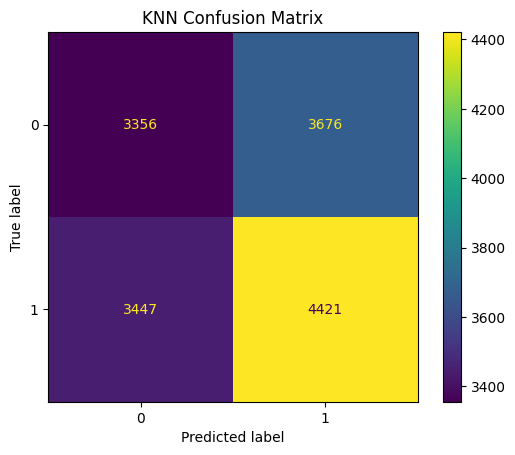

In [53]:
cm_knn_s1 = confusion_matrix(y_test_s1, y_pred_knn_s1)
ConfusionMatrixDisplay(cm_knn_s1).plot()
plt.title('KNN Confusion Matrix')
plt.show()

In [54]:
accuracy_knn_s1 = accuracy_score(y_test_s1, y_pred_knn_s1)
precision_knn_s1 = precision_score(y_test_s1, y_pred_knn_s1)
recall_knn_s1 = recall_score(y_test_s1, y_pred_knn_s1)
f1_knn_s1 = f1_score(y_test_s1, y_pred_knn_s1)

print(f"KNN Accuracy: {accuracy_knn_s1:.4f}")
print(f"KNN Precision: {precision_knn_s1:.4f}")
print(f"KNN Recall: {recall_knn_s1:.4f}")
print(f"KNN F1-score: {f1_knn_s1:.4f}")

KNN Accuracy: 0.5219
KNN Precision: 0.5460
KNN Recall: 0.5619
KNN F1-score: 0.5538


## Naive Bayes Baseline

In [55]:
nb = GaussianNB()

In [56]:
nb.fit(X_train_s1, y_train_s1)
y_pred_nb_s1 = nb.predict(X_test_s1)

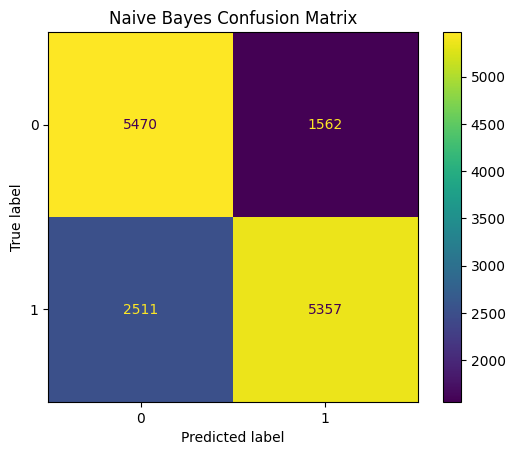

In [57]:
cm_nb_s1 = confusion_matrix(y_test_s1, y_pred_nb_s1)
ConfusionMatrixDisplay(cm_nb_s1).plot()
plt.title('Naive Bayes Confusion Matrix')
plt.show()

In [58]:
accuracy_nb_s1 = accuracy_score(y_test_s1, y_pred_nb_s1)
precision_nb_s1 = precision_score(y_test_s1, y_pred_nb_s1)
recall_nb_s1 = recall_score(y_test_s1, y_pred_nb_s1)
f1_nb_s1 = f1_score(y_test_s1, y_pred_nb_s1)

print(f"Naive Bayes Accuracy: {accuracy_nb_s1:.4f}")
print(f"Naive Bayes Precision: {precision_nb_s1:.4f}")
print(f"Naive Bayes Recall: {recall_nb_s1:.4f}")
print(f"Naive Bayes F1-score: {f1_nb_s1:.4f}")

Naive Bayes Accuracy: 0.7266
Naive Bayes Precision: 0.7742
Naive Bayes Recall: 0.6809
Naive Bayes F1-score: 0.7246


## Random Forest Baseline

In [59]:
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

In [60]:
rf.fit(X_train_s1, y_train_s1)
y_pred_rf_s1 = rf.predict(X_test_s1)

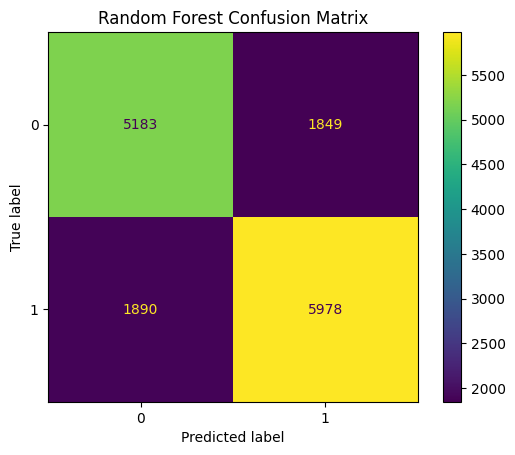

In [61]:
cm_rf_s1 = confusion_matrix(y_test_s1, y_pred_rf_s1)
ConfusionMatrixDisplay(cm_rf_s1).plot()
plt.title('Random Forest Confusion Matrix')
plt.show()

In [62]:
accuracy_rf_s1 = accuracy_score(y_test_s1, y_pred_rf_s1)
precision_rf_s1 = precision_score(y_test_s1, y_pred_rf_s1)
recall_rf_s1 = recall_score(y_test_s1, y_pred_rf_s1)
f1_rf_s1 = f1_score(y_test_s1, y_pred_rf_s1)

print(f"Random Forest Accuracy: {accuracy_rf_s1:.4f}")
print(f"Random Forest Precision: {precision_rf_s1:.4f}")
print(f"Random Forest Recall: {recall_rf_s1:.4f}")
print(f"Random Forest F1-score: {f1_rf_s1:.4f}")

Random Forest Accuracy: 0.7491
Random Forest Precision: 0.7638
Random Forest Recall: 0.7598
Random Forest F1-score: 0.7618


## Scenario 1 Comparison

In [63]:
performance_metrics_s1 = [
    ['KNN', accuracy_knn_s1, precision_knn_s1, recall_knn_s1, f1_knn_s1],
    ['Naive Bayes', accuracy_nb_s1, precision_nb_s1, recall_nb_s1, f1_nb_s1],
    ['Random Forest', accuracy_rf_s1, precision_rf_s1, recall_rf_s1, f1_rf_s1]
]

metrics_s1_df = pd.DataFrame(
    performance_metrics_s1,
    columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score']
)

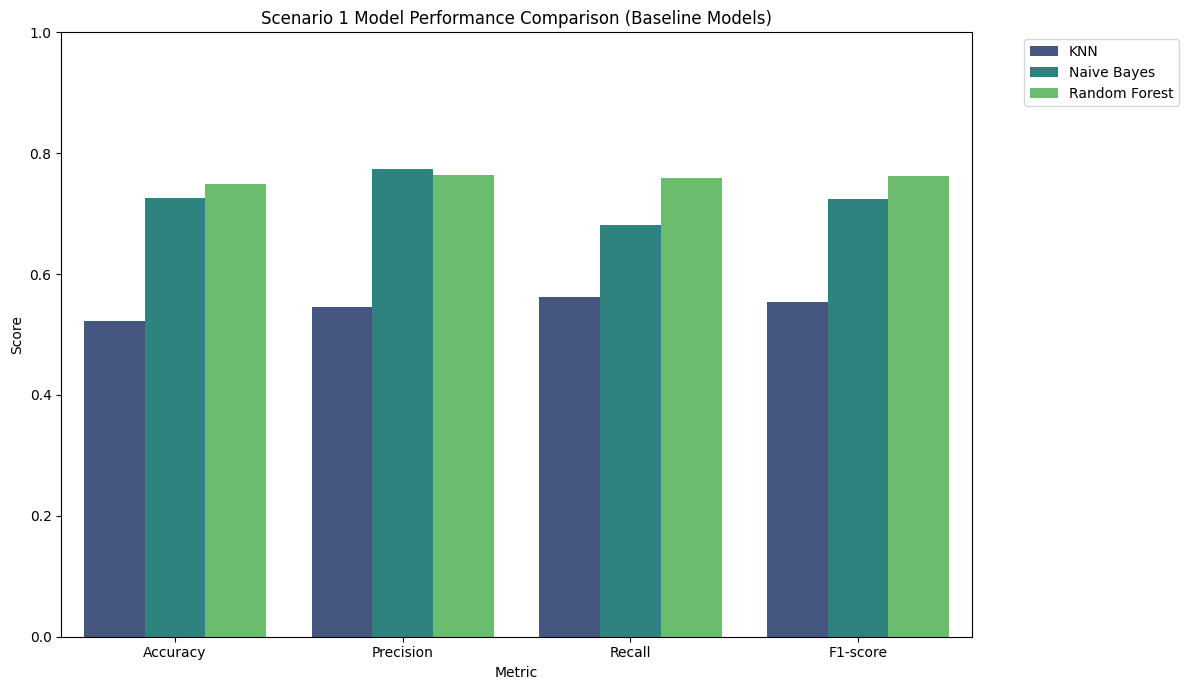

In [64]:
metrics_s1_df_melted = metrics_s1_df.melt(
    id_vars=['Model'],
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(12, 7))
sns.barplot(
    x='Metric',
    y='Score',
    hue='Model',
    data=metrics_s1_df_melted,
    palette='viridis'
)
plt.title('Scenario 1 Model Performance Comparison (Baseline Models)')
plt.ylabel('Score')
plt.xlabel('Metric')
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Scenario 2: *Baseline Models + Feature Selection + Normalization*

## Scenarion 2 Dataset Preparation

In [65]:
X_train_s2 = X_train_scaled.copy()
X_test_s2 = X_test_scaled.copy()

In [66]:
y_train_s2 = y_train.copy()
y_test_s2 = y_test.copy()

## KNN

In [67]:
knn = KNeighborsClassifier(n_neighbors=5)

In [68]:
knn.fit(X_train_s2, y_train_s2)
y_pred_knn_s2 = knn.predict(X_test_s2)

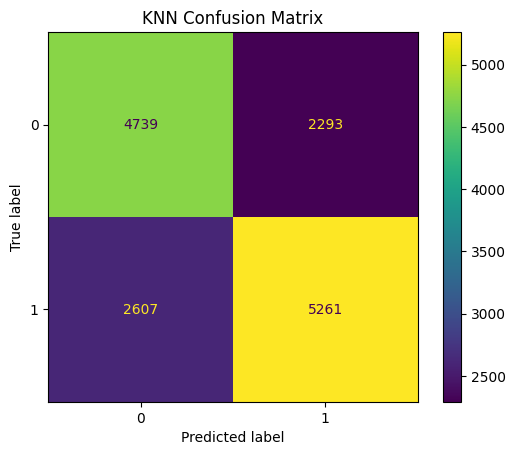

In [69]:
cm_knn_s2 = confusion_matrix(y_test_s2, y_pred_knn_s2)
ConfusionMatrixDisplay(cm_knn_s2).plot()
plt.title('KNN Confusion Matrix')
plt.show()

In [70]:
accuracy_knn_s2 = accuracy_score(y_test_s2, y_pred_knn_s2)
precision_knn_s2 = precision_score(y_test_s2, y_pred_knn_s2)
recall_knn_s2 = recall_score(y_test_s2, y_pred_knn_s2)
f1_knn_s2 = f1_score(y_test_s2, y_pred_knn_s2)

print(f"KNN Accuracy: {accuracy_knn_s2:.4f}")
print(f"KNN Precision: {precision_knn_s2:.4f}")
print(f"KNN Recall: {recall_knn_s2:.4f}")
print(f"KNN F1-score: {f1_knn_s2:.4f}")

KNN Accuracy: 0.6711
KNN Precision: 0.6965
KNN Recall: 0.6687
KNN F1-score: 0.6823


## Naive Bayes

In [71]:
nb = GaussianNB()

In [72]:
nb.fit(X_train_s2, y_train_s2)
y_pred_nb_s2 = nb.predict(X_test_s2)

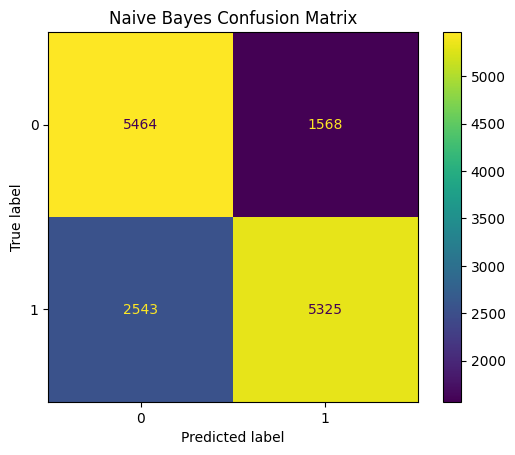

In [73]:
cm_nb_s2 = confusion_matrix(y_test_s2, y_pred_nb_s2)
ConfusionMatrixDisplay(cm_nb_s2).plot()
plt.title('Naive Bayes Confusion Matrix')
plt.show()

In [74]:
accuracy_nb_s2 = accuracy_score(y_test_s2, y_pred_nb_s2)
precision_nb_s2 = precision_score(y_test_s2, y_pred_nb_s2)
recall_nb_s2 = recall_score(y_test_s2, y_pred_nb_s2)
f1_nb_s2 = f1_score(y_test_s2, y_pred_nb_s2)

print(f"Naive Bayes Accuracy: {accuracy_nb_s2:.4f}")
print(f"Naive Bayes Precision: {precision_nb_s2:.4f}")
print(f"Naive Bayes Recall: {recall_nb_s2:.4f}")
print(f"Naive Bayes F1-score: {f1_nb_s2:.4f}")

Naive Bayes Accuracy: 0.7241
Naive Bayes Precision: 0.7725
Naive Bayes Recall: 0.6768
Naive Bayes F1-score: 0.7215


## Random Forest

In [75]:
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

In [76]:
rf.fit(X_train_s2, y_train_s2)
y_pred_rf_s2 = rf.predict(X_test_s2)

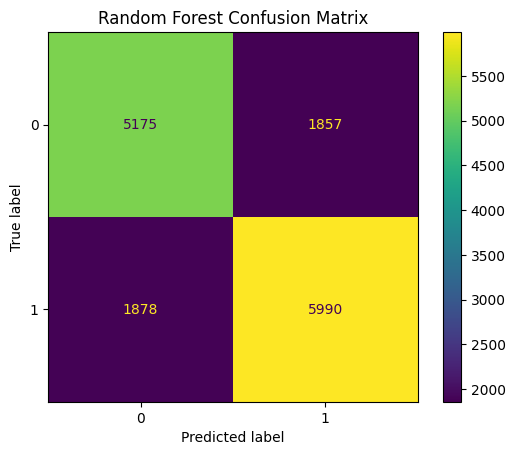

In [77]:
cm_rf_s2 = confusion_matrix(y_test_s2, y_pred_rf_s2)
ConfusionMatrixDisplay(cm_rf_s2).plot()
plt.title('Random Forest Confusion Matrix')
plt.show()

In [78]:
accuracy_rf_s2 = accuracy_score(y_test_s2, y_pred_rf_s2)
precision_rf_s2 = precision_score(y_test_s2, y_pred_rf_s2)
recall_rf_s2 = recall_score(y_test_s2, y_pred_rf_s2)
f1_rf_s2 = f1_score(y_test_s2, y_pred_rf_s2)

print(f"Random Forest Accuracy: {accuracy_rf_s2:.4f}")
print(f"Random Forest Precision: {precision_rf_s2:.4f}")
print(f"Random Forest Recall: {recall_rf_s2:.4f}")
print(f"Random Forest F1-score: {f1_rf_s2:.4f}")

Random Forest Accuracy: 0.7493
Random Forest Precision: 0.7633
Random Forest Recall: 0.7613
Random Forest F1-score: 0.7623


## Scenario 2 Comparison

In [79]:
performance_metrics_s2 = [
    ['KNN', accuracy_knn_s2, precision_knn_s2, recall_knn_s2, f1_knn_s2],
    ['Naive Bayes', accuracy_nb_s2, precision_nb_s2, recall_nb_s2, f1_nb_s2],
    ['Random Forest', accuracy_rf_s2, precision_rf_s2, recall_rf_s2, f1_rf_s2]
]

metrics_s2_df = pd.DataFrame(
    performance_metrics_s2,
    columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score']
)

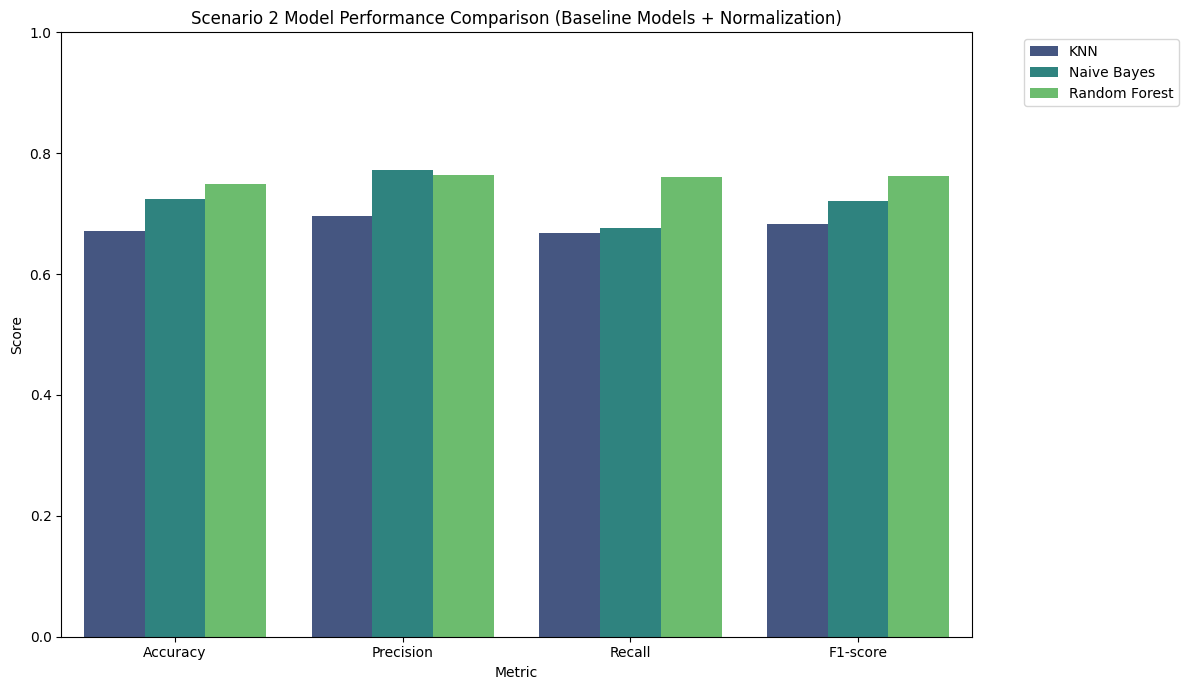

In [80]:
metrics_s2_df_melted = metrics_s2_df.melt(
    id_vars=['Model'],
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(12, 7))
sns.barplot(
    x='Metric',
    y='Score',
    hue='Model',
    data=metrics_s2_df_melted,
    palette='viridis'
)
plt.title('Scenario 2 Model Performance Comparison (Baseline Models + Normalization)')
plt.ylabel('Score')
plt.xlabel('Metric')
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Scenario 3: *Tuned Models + Feature Selection + Normalization*

## Scenario 3 Dataset Preparation

In [81]:
X_train_s3 = X_train_scaled.copy()
X_test_s3 = X_test_scaled.copy()

In [82]:
y_train_s3 = y_train.copy()
y_test_s3 = y_test.copy()

## Hyperparameter Tuning

### KNN Tuning

In [83]:
param_grid_knn = {
    "n_neighbors": [3, 5, 7, 9],
    "weights": ["uniform", "distance"],
    "p": [1, 2]
}

In [84]:
grid_search_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid_knn,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    return_train_score=True
)

In [85]:
grid_search_knn.fit(X_train_s3, y_train_s3 )

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': [3, 5, 7, 9], 'p': [1, 2],
                         'weights': ['uniform', 'distance']},
             return_train_score=True, scoring='f1')

In [86]:
print("Best Parameters:")
print(grid_search_knn.best_params_)

Best Parameters:
{'n_neighbors': 9, 'p': 1, 'weights': 'uniform'}


In [87]:
print("Best CV F1:")
print(grid_search_knn.best_score_)

Best CV F1:
0.7038344838441475


In [88]:
best_knn = grid_search_knn.best_estimator_

### Naive Bayes Tuning

In [89]:
param_grid_nb = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

In [90]:
grid_search_nb = GridSearchCV(
    GaussianNB(),
    param_grid_nb,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

In [91]:
grid_search_nb.fit(X_train_s3, y_train_s3)

GridSearchCV(cv=5, estimator=GaussianNB(), n_jobs=-1,
             param_grid={'var_smoothing': array([1.00000000e+00, 8.11130831e-01, 6.57933225e-01, 5.33669923e-01,
       4.32876128e-01, 3.51119173e-01, 2.84803587e-01, 2.31012970e-01,
       1.87381742e-01, 1.51991108e-01, 1.23284674e-01, 1.00000000e-01,
       8.11130831e-02, 6.57933225e-02, 5.33669923e-02, 4.32876128e-02,
       3.51119173e-02, 2.8480358...
       1.23284674e-07, 1.00000000e-07, 8.11130831e-08, 6.57933225e-08,
       5.33669923e-08, 4.32876128e-08, 3.51119173e-08, 2.84803587e-08,
       2.31012970e-08, 1.87381742e-08, 1.51991108e-08, 1.23284674e-08,
       1.00000000e-08, 8.11130831e-09, 6.57933225e-09, 5.33669923e-09,
       4.32876128e-09, 3.51119173e-09, 2.84803587e-09, 2.31012970e-09,
       1.87381742e-09, 1.51991108e-09, 1.23284674e-09, 1.00000000e-09])},
             scoring='f1')

In [92]:
print("Best Parameters:")
print(grid_search_nb.best_params_)

Best Parameters:
{'var_smoothing': np.float64(0.1873817422860384)}


In [93]:
print("Best CV F1:")
print(grid_search_nb.best_score_)

Best CV F1:
0.7399046321009848


In [94]:
best_nb = grid_search_nb.best_estimator_

### Random Forest Tuning

In [95]:
param_dist_rf = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'criterion': ['gini', 'entropy'],
    'ccp_alpha': [0.0, 0.001, 0.005]
}

In [96]:
random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=30,
    scoring='f1',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

In [97]:
random_search_rf.fit(X_train_s3, y_train_s3)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END ccp_alpha=0.001, criterion=gini, max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=500; total time=  35.9s
[CV] END ccp_alpha=0.005, criterion=gini, max_depth=10, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=  11.5s
[CV] END ccp_alpha=0.005, criterion=gini, max_depth=10, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=  11.3s
[CV] END ccp_alpha=0.001, criterion=gini, max_depth=10, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   5.8s
[CV] END ccp_alpha=0.005, criterion=entropy, max_depth=10, max_features=log2, min_samples_leaf=2, min_samples_split=10, n_estimators=300; total time=  17.0s
[CV] END ccp_alpha=0.005, criterion=gini, max_depth=20, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time= 3.8min
[CV] END ccp_al

RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'ccp_alpha': [0.0, 0.001, 0.005],
                                        'criterion': ['gini', 'entropy'],
                                        'max_depth': [10, 20, 30, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, return_train_score=True, scoring='f1',
                   verbose=2)

In [98]:
print("Best Parameters:")
print(random_search_rf.best_params_)

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 30, 'criterion': 'entropy', 'ccp_alpha': 0.0}


In [99]:
print("Best CV F1:")
print(random_search_rf.best_score_)

Best CV F1:
0.7644228053465578


In [100]:
best_rf = random_search_rf.best_estimator_

## KNN Tuned

In [101]:
best_knn.fit(X_train_s3, y_train_s3)
y_pred_knn_s3 = best_knn.predict(X_test_s3)

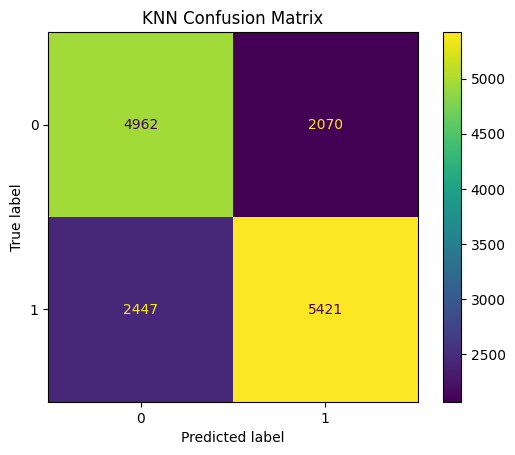

In [102]:
cm_knn_s3 = confusion_matrix(y_test_s3, y_pred_knn_s3)
ConfusionMatrixDisplay(cm_knn_s3).plot()
plt.title('KNN Confusion Matrix')
plt.show()

In [103]:
accuracy_knn_s3 = accuracy_score(y_test_s3, y_pred_knn_s3)
precision_knn_s3 = precision_score(y_test_s3, y_pred_knn_s3)
recall_knn_s3 = recall_score(y_test_s3, y_pred_knn_s3)
f1_knn_s3 = f1_score(y_test_s3, y_pred_knn_s3)

print(f"KNN Accuracy: {accuracy_knn_s3:.4f}")
print(f"KNN Precision: {precision_knn_s3:.4f}")
print(f"KNN Recall: {recall_knn_s3:.4f}")
print(f"KNN F1-score: {f1_knn_s3:.4f}")

KNN Accuracy: 0.6968
KNN Precision: 0.7237
KNN Recall: 0.6890
KNN F1-score: 0.7059


## Naive Bayes Tuned

In [104]:
best_nb.fit(X_train_s3, y_train_s3)
y_pred_nb_s3 = best_nb.predict(X_test_s3)

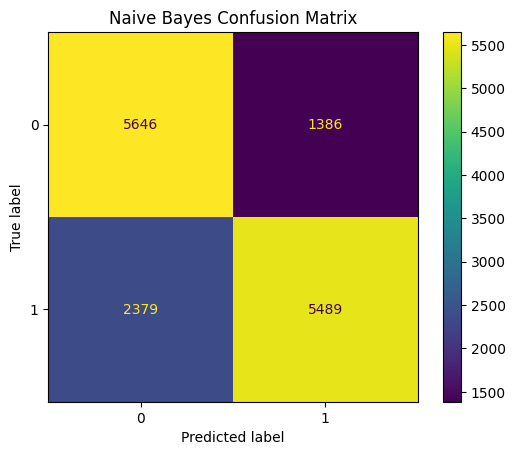

In [105]:
cm_nb_s3 = confusion_matrix(y_test_s3, y_pred_nb_s3)
ConfusionMatrixDisplay(cm_nb_s3).plot()
plt.title('Naive Bayes Confusion Matrix')
plt.show()

In [106]:
accuracy_nb_s3 = accuracy_score(y_test_s3, y_pred_nb_s3)
precision_nb_s3 = precision_score(y_test_s3, y_pred_nb_s3)
recall_nb_s3 = recall_score(y_test_s3, y_pred_nb_s3)
f1_nb_s3 = f1_score(y_test_s3, y_pred_nb_s3)

print(f"Naive Bayes Accuracy: {accuracy_nb_s3:.4f}")
print(f"Naive Bayes Precision: {precision_nb_s3:.4f}")
print(f"Naive Bayes Recall: {recall_nb_s3:.4f}")
print(f"Naive Bayes F1-score: {f1_nb_s3:.4f}")

Naive Bayes Accuracy: 0.7473
Naive Bayes Precision: 0.7984
Naive Bayes Recall: 0.6976
Naive Bayes F1-score: 0.7446


## Random Forest Tuned

In [107]:
best_rf.fit(X_train_s3, y_train_s3)
y_pred_rf_s3 = best_rf.predict(X_test_s3)

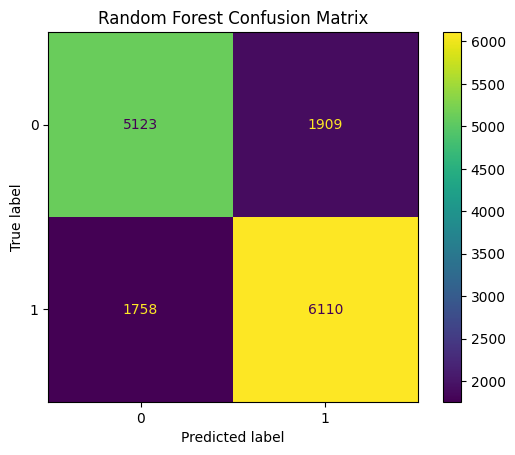

In [108]:
cm_rf_s3 = confusion_matrix(y_test_s3, y_pred_rf_s3)
ConfusionMatrixDisplay(cm_rf_s3).plot()
plt.title('Random Forest Confusion Matrix')
plt.show()

In [109]:
accuracy_rf_s3 = accuracy_score(y_test_s3, y_pred_rf_s3)
precision_rf_s3 = precision_score(y_test_s3, y_pred_rf_s3)
recall_rf_s3 = recall_score(y_test_s3, y_pred_rf_s3)
f1_rf_s3 = f1_score(y_test_s3, y_pred_rf_s3)

print(f"Random Forest Accuracy: {accuracy_rf_s3:.4f}")
print(f"Random Forest Precision: {precision_rf_s3:.4f}")
print(f"Random Forest Recall: {recall_rf_s3:.4f}")
print(f"Random Forest F1-score: {f1_rf_s3:.4f}")

Random Forest Accuracy: 0.7539
Random Forest Precision: 0.7619
Random Forest Recall: 0.7766
Random Forest F1-score: 0.7692


## Scenario 3 Comparison

In [110]:
performance_metrics_s3 = [
    ['KNN', accuracy_knn_s3, precision_knn_s3, recall_knn_s3, f1_knn_s3],
    ['Naive Bayes', accuracy_nb_s3, precision_nb_s3, recall_nb_s3, f1_nb_s3],
    ['Random Forest', accuracy_rf_s3, precision_rf_s3, recall_rf_s3, f1_rf_s3]
]

metrics_s3_df = pd.DataFrame(
    performance_metrics_s3,
    columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score']
)

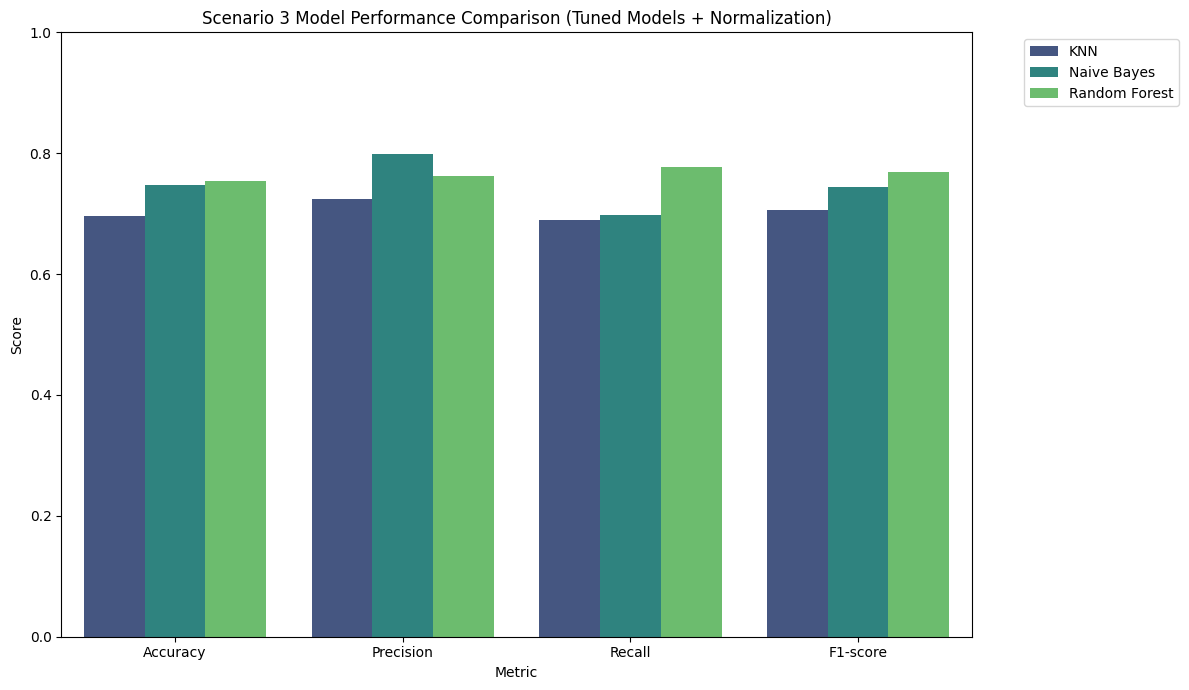

In [111]:
metrics_s3_df_melted = metrics_s3_df.melt(
    id_vars=['Model'],
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(12, 7))
sns.barplot(
    x='Metric',
    y='Score',
    hue='Model',
    data=metrics_s3_df_melted,
    palette='viridis'
)
plt.title('Scenario 3 Model Performance Comparison (Tuned Models + Normalization)')
plt.ylabel('Score')
plt.xlabel('Metric')
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Overall Comparison

## Comparison Across Scenarios

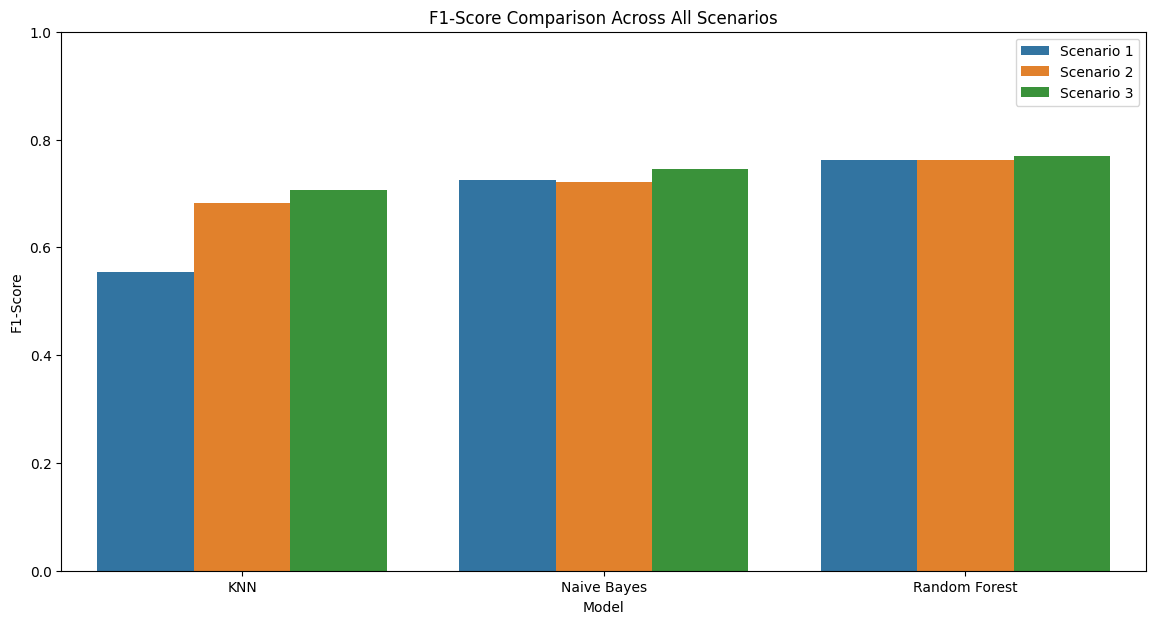

,Model,Accuracy,Precision,Recall,F1-score,Scenario
8,Random Forest,0.753893,0.761940,0.776563,0.769182,Scenario 3
5,Random Forest,0.749329,0.763349,0.761312,0.762329,Scenario 2
2,Random Forest,0.749060,0.763766,0.759786,0.761771,Scenario 1
7,Naive Bayes,0.747315,0.798400,0.697636,0.744625,Scenario 3
1,Naive Bayes,0.726644,0.774245,0.680859,0.724555,Scenario 1
4,Naive Bayes,0.724094,0.772523,0.676792,0.721496,Scenario 2
6,KNN,0.696846,0.723668,0.688993,0.705905,Scenario 3
3,KNN,0.671141,0.696452,0.668658,0.682272,Scenario 2
0,KNN,0.521946,0.546005,0.561896,0.553837,Scenario 1


In [112]:
metrics_s1_df['Scenario'] = 'Scenario 1'
metrics_s2_df['Scenario'] = 'Scenario 2'
metrics_s3_df['Scenario'] = 'Scenario 3'

all_scenarios_df = pd.concat([metrics_s1_df, metrics_s2_df, metrics_s3_df], ignore_index=True)

plt.figure(figsize=(14, 7))
sns.barplot(data=all_scenarios_df, x='Model', y='F1-score', hue='Scenario')
plt.title('F1-Score Comparison Across All Scenarios')
plt.ylabel('F1-Score')
plt.ylim(0, 1)
plt.legend(loc='upper right')
plt.show()

display(all_scenarios_df.sort_values(by='F1-score', ascending=False))

## Best Model Selection

In [113]:
best_model_idx = all_scenarios_df['F1-score'].idxmax()
best_model_row = all_scenarios_df.iloc[best_model_idx]

print(f"Model Terbaik Berdasarkan F1-Score:")
print(f"- Model   : {best_model_row['Model']}")
print(f"- Scenario: {best_model_row['Scenario']}")
print(f"- F1-Score: {best_model_row['F1-score']:.4f}")

Model Terbaik Berdasarkan F1-Score:
- Model   : Random Forest
- Scenario: Scenario 3
- F1-Score: 0.7692


# Feature Importance Analysis

In [114]:
importances = best_rf.feature_importances_
feature_names = all_processed_cols

In [115]:
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

top15_importance = importance_df.sort_values(by='Importance', ascending=False).head(15)

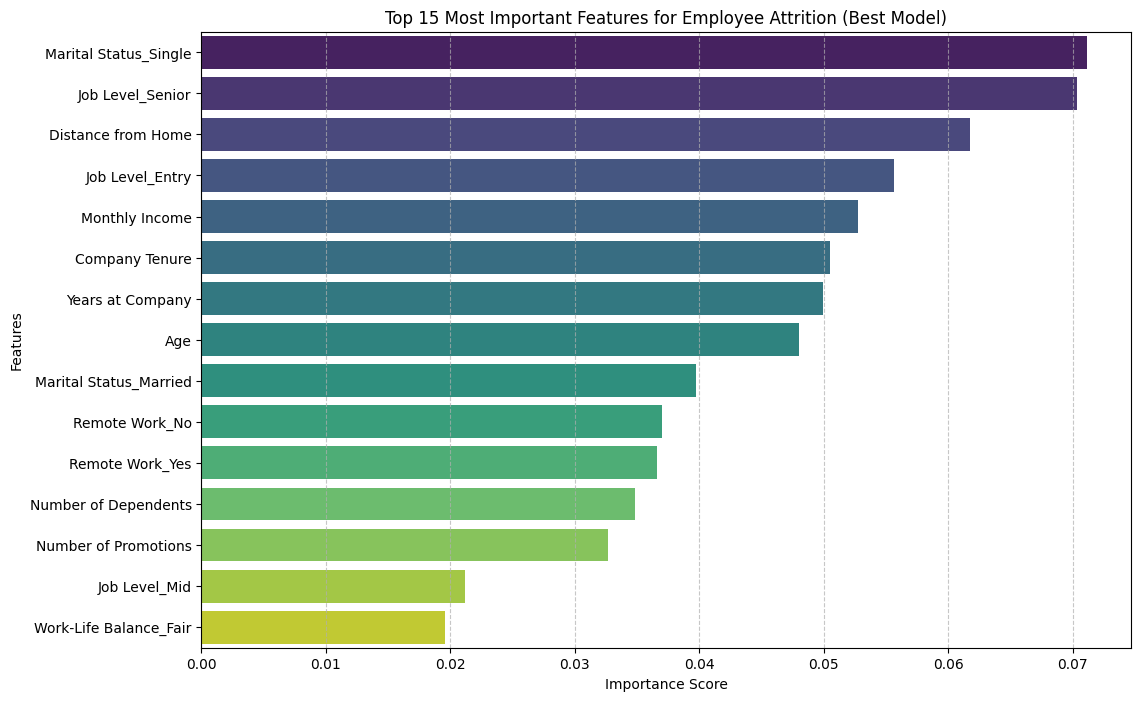

In [116]:
plt.figure(figsize=(12, 8))
sns.barplot(
    data=top15_importance, 
    x='Importance', 
    y='Feature', 
    palette='viridis'
)

plt.title('Top 15 Most Important Features for Employee Attrition (Best Model)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Conclusion